# Retail Sales Analysis using Python

## Project Objective

The goal of this project is to analyze online retail sales data and understand - Sales trends, Customer behaviour, Top products and Revenue patterns

# Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load Dataset

In [2]:
df1 = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2009-2010')
df2 = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2010-2011')

df = pd.concat([df1, df2])
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


# Understanding the Dataset

In [3]:
df.shape

(1067371, 8)

In [4]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1067371 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 73.3+ MB


In [6]:
df.describe()    

,Quantity,InvoiceDate,Price,Customer ID
count,1.067371e+06,1067371,1.067371e+06,824364.000000
mean,9.938898e+00,2011-01-02 21:13:55.394028544,4.649388e+00,15324.638504
min,-8.099500e+04,2009-12-01 07:45:00,-5.359436e+04,12346.000000
25%,1.000000e+00,2010-07-09 09:46:00,1.250000e+00,13975.000000
50%,3.000000e+00,2010-12-07 15:28:00,2.100000e+00,15255.000000
75%,1.000000e+01,2011-07-22 10:23:00,4.150000e+00,16797.000000
max,8.099500e+04,2011-12-09 12:50:00,3.897000e+04,18287.000000
std,1.727058e+02,NaN,1.235531e+02,1697.464450


# Data Cleaning

In [7]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [8]:
df.columns = df.columns.str.lower().str.replace(' ','_')

In [9]:
df[
    df['description'].isnull() &
    df['customer_id'].isnull()
].shape[0]

4382

every row with a missing decription also has missing customer_id so remove them

In [10]:
df = df.dropna(subset=['description'])

In [11]:
df.duplicated().sum()

np.int64(34228)

In [12]:
df[df.duplicated()].head(25)

,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
383,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom
384,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329.0,United Kingdom
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
386,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
390,489517,84951A,S/4 PISTACHIO LOVEBIRD COASTERS,1,2009-12-01 11:34:00,2.55,16329.0,United Kingdom
391,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329.0,United Kingdom
394,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
657,489529,22028,PENNY FARTHING BIRTHDAY CARD,12,2009-12-01 11:51:00,0.42,17984.0,United Kingdom
658,489529,22036,DINOSAUR BIRTHDAY CARD,12,2009-12-01 11:51:00,0.42,17984.0,United Kingdom


There are duplicated recoreds, so I will remove them

In [13]:
df = df.drop_duplicates()

Since the analysis focused on completed sales and revenue generation, all non-positive quantites and prices need to be removed.

In [14]:
df = df = df[df['quantity']>0]

In [15]:
df = df[df['price']>0]

# Feature Engineering

In [16]:
df['revenue'] = df['quantity'] * df['price']

In [17]:
df['invoicedate'] = pd.to_datetime(df['invoicedate'])

In [18]:
df['month'] = df['invoicedate'].dt.month

In [19]:
df['hour'] = df['invoicedate'].dt.hour

# KPI Summary

In [20]:
total_revenue = df['revenue'].sum()
total_orders = df['invoice'].nunique()
total_customers = df['customer_id'].nunique()
total_products_sold = df['quantity'].sum()
average_order_value = total_revenue / total_orders

print("Total Revenue:", round(total_revenue, 2))
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Total Products Sold:", total_products_sold)
print("Average Order Value:", round(average_order_value, 2))

Total Revenue: 20476634.02
Total Orders: 40078
Total Customers: 5878
Total Products Sold: 11205149
Average Order Value: 510.92


# Checking outliers

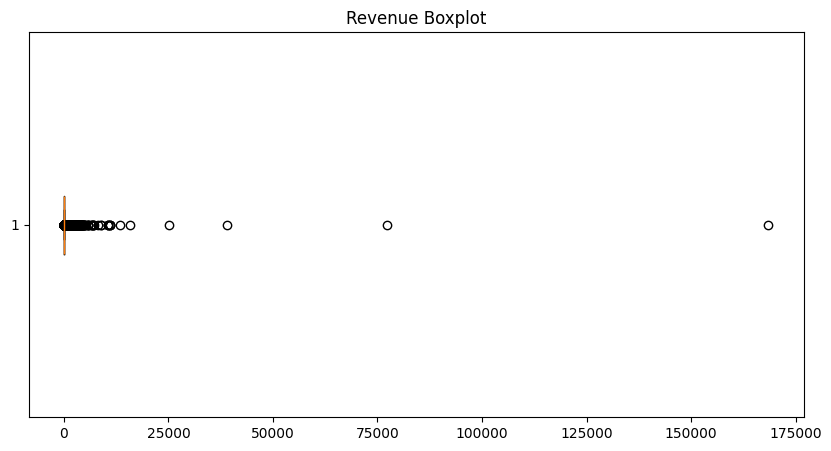

In [21]:
plt.figure(figsize=(10,5))
plt.boxplot(df['revenue'], vert=False)

plt.title('Revenue Boxplot')

plt.show()

In [22]:
df.sort_values(by='revenue',ascending=False).head(10)

,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country,revenue,month,hour
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom,168469.60,12,9
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom,77183.60,1,10
222671,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,2011-06-10 15:28:00,649.50,15098.0,United Kingdom,38970.00,6,15
241827,512771,M,Manual,1,2010-06-17 16:53:00,25111.09,NaN,United Kingdom,25111.09,6,16
432176,530715,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,9360,2010-11-04 11:36:00,1.69,15838.0,United Kingdom,15818.40,11,11
517955,537632,AMAZONFEE,AMAZON FEE,1,2010-12-07 15:08:00,13541.33,NaN,United Kingdom,13541.33,12,15
299982,A563185,B,Adjust bad debt,1,2011-08-12 14:50:00,11062.06,NaN,United Kingdom,11062.06,8,14
135015,502265,M,Manual,1,2010-03-23 15:28:00,10953.50,NaN,United Kingdom,10953.50,3,15
135013,502263,M,Manual,1,2010-03-23 15:22:00,10953.50,12918.0,United Kingdom,10953.50,3,15
358639,524159,M,Manual,1,2010-09-27 16:12:00,10468.80,14063.0,United Kingdom,10468.80,9,16


The dataset contains operational/accounting transactions mixed with retail sales.

In [23]:
df[
    df['description'].str.contains(
        'manual|adjust|amazon fee|check',
        case=False,
        na=False
    )
]['description'].value_counts()

description
Manual                                 852
BROWN CHECK CAT DOORSTOP               455
SUNSET CHECK HAMMOCK                   113
PAIR PADDED HANGERS PINK CHECK          96
Adjustment by john on 26/01/2010 16     20
MULTICOLOUR CRUSOE CHECK LAMPSHADE      17
Adjustment by john on 26/01/2010 17     16
BLUE CHECK BAG W HANDLE 34X20CM         10
BLUE CRUSOE CHECK LAMPSHADE              6
Adjustment by Peter on Jun 25 2010       3
AMAZON FEE                               3
Adjust bad debt                          1
Name: count, dtype: int64

Removing those operational/accounting transactions

In [24]:
df = df[
    ~df['description'].str.contains(
        'Manual|Adjustment|AMAZON FEE|Adjust bad debt',
        case=False,
        na=False
    )
]

## Monthly Revenue Trend

In [25]:
df['year_month'] = df['invoicedate'].dt.to_period('M')

In [26]:
monthly_sales = df.groupby('year_month')['revenue'].sum()

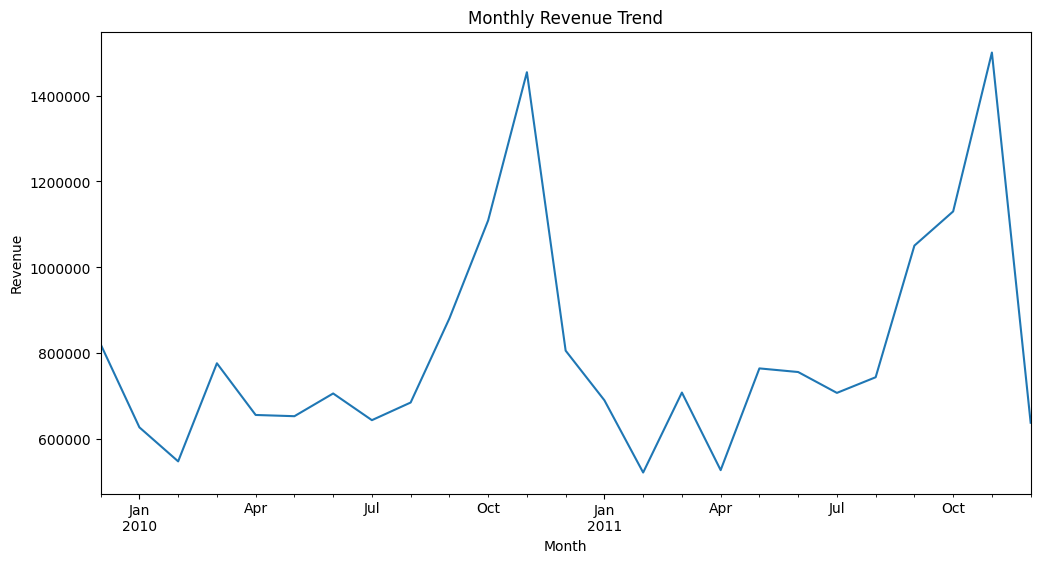

In [27]:
plt.figure(figsize=(12,6))

monthly_sales.plot()

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.ticklabel_format(style='plain', axis='y')

plt.show()

### Insights

1. Revenue increased during later months of both years which suggests possible seasonal sales trends or holiday shopping impact.
2. A revenue drop can also be seen after peak months which may indicate reduced customer activity or seasonal demand decline.
3. The business can use these trends for better inventory planning, marketing campaigns, and sales forecasting.

## Monthly Order Volume

In [28]:
monthly_orders = df.groupby('year_month')['invoice'].nunique()

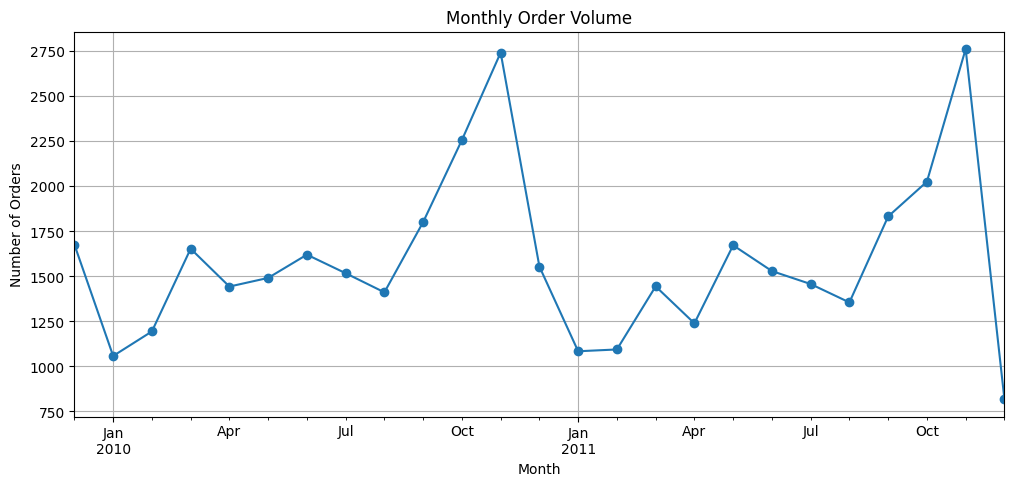

In [29]:
plt.figure(figsize=(12,5))

monthly_orders.plot(marker='o')

plt.title('Monthly Order Volume')
plt.xlabel('Month')
plt.ylabel('Number of Orders')

plt.grid(True)

plt.show()

### Insights

1. Order volume increased significantly during the final months of both years, which indicates higher customer demand during peak sales periods.
2. A sharp decline in orders can be observed after peak months, suggesting a reduction in customer activity during off season periods.
3. Understanding monthly order patterns helps businesses improve inventory planning, workforce management, and marketing strategies.

## Top products by quantity sold

In [30]:
product_df = df[
    ~df['description'].str.contains(
        'POSTAGE|DOTCOM POSTAGE',
        case=False,
        na=False)]

In [31]:
top_products = product_df.groupby('description')['quantity'].sum().sort_values(ascending = False).head(10)
top_products

description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     106139
WHITE HANGING HEART T-LIGHT HOLDER     94658
PAPER CRAFT , LITTLE BIRDIE            80995
ASSORTED COLOUR BIRD ORNAMENT          80082
MEDIUM CERAMIC TOP STORAGE JAR         78033
JUMBO BAG RED RETROSPOT                77699
BROCADE RING PURSE                     70369
PACK OF 60 PINK PAISLEY CAKE CASES     56061
60 TEATIME FAIRY CAKE CASES            54028
SMALL POPCORN HOLDER                   48561
Name: quantity, dtype: int64

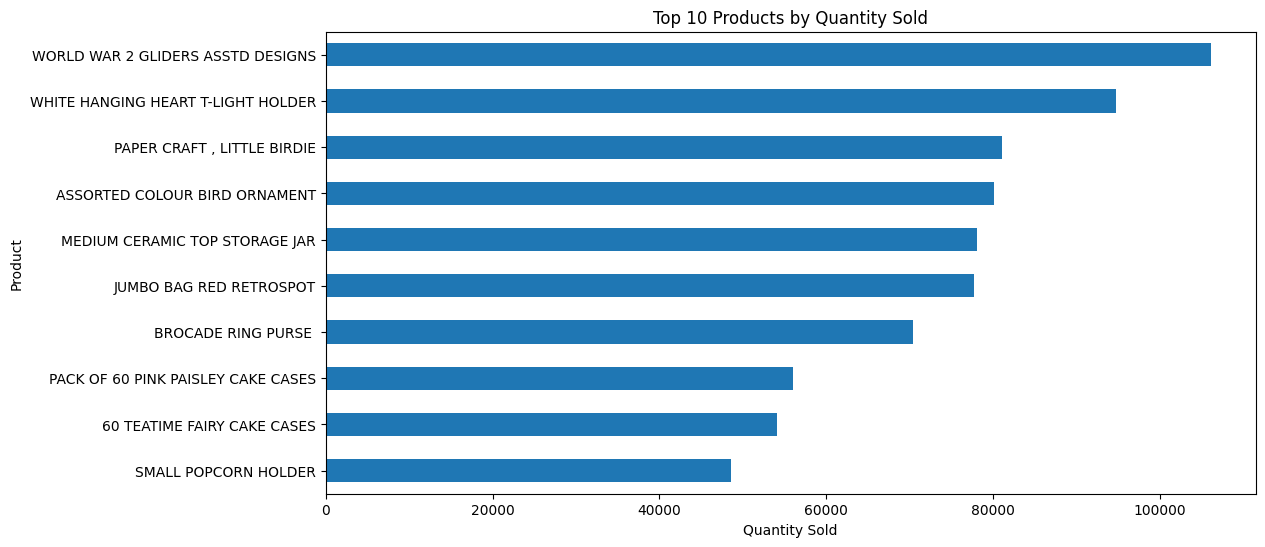

In [32]:
plt.figure(figsize=(12,6))

top_products.sort_values().plot(kind='barh')

plt.title('Top 10 Products by Quantity Sold')
plt.xlabel('Quantity Sold')
plt.ylabel('Product')

plt.show()

### Insights

1. WORLD WAR 2 GLIDERS ASSTD DESIGNS is the highest selling product (approx 106K units sold).
2. WHITE HANGING HEART T-LIGHT HOLDER  is the second highest selling product (approx. 94K units sold).
3. Products ranked 3rd to 6th have similar sales volumes (around 78K to 81K).
4. The top selling list is dominated by home decor, gift items, and decorative accessories which suggests these categories drive customer purchases.

## Top Revenue Generating Products

In [33]:
top_revenue_products =  product_df.groupby('description')['revenue'].sum().sort_values(ascending = False).head(10)
top_revenue_products

description
REGENCY CAKESTAND 3 TIER               330590.32
WHITE HANGING HEART T-LIGHT HOLDER     260990.22
PAPER CRAFT , LITTLE BIRDIE            168469.60
PARTY BUNTING                          148318.28
JUMBO BAG RED RETROSPOT                148073.47
ASSORTED COLOUR BIRD ORNAMENT          129324.49
PAPER CHAIN KIT 50'S CHRISTMAS         117760.29
MEDIUM CERAMIC TOP STORAGE JAR          81700.92
CHILLI LIGHTS                           80540.88
ROTATING SILVER ANGELS T-LIGHT HLDR     71300.40
Name: revenue, dtype: float64

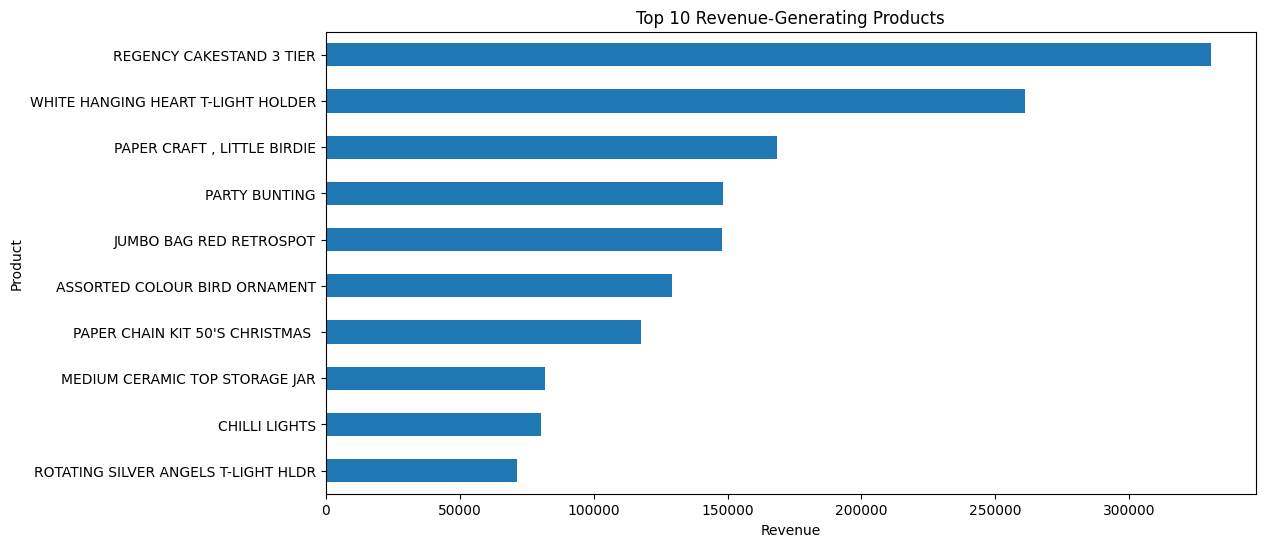

In [34]:
plt.figure(figsize = (12,6))

top_revenue_products.sort_values().plot(kind='barh')

plt.title('Top 10 Revenue-Generating Products')
plt.xlabel('Revenue')
plt.ylabel('Product')

plt.ticklabel_format(style = 'plain', axis = 'x')

plt.show()

### Insights

1. REGENCY CAKESTAND 3 TIER is the highest revenue generating product (contributing over GBP 330K in sales)
2. WHITE HANGING HEART T-LIGHT HOLDER combines strong sales volume with high revenue which makes it key business product.
3. High sales volume does not always means high revenue, as we seen with the WORLD WAR 2 GLIDERS ASSTD DESIGNS.
4. Home decor and gift items dominate the top revenue generating products.
5. Revenue performance suggests customers are willing to spend more on decorative and lifestyle products.

## Country wise Revenue Analysis

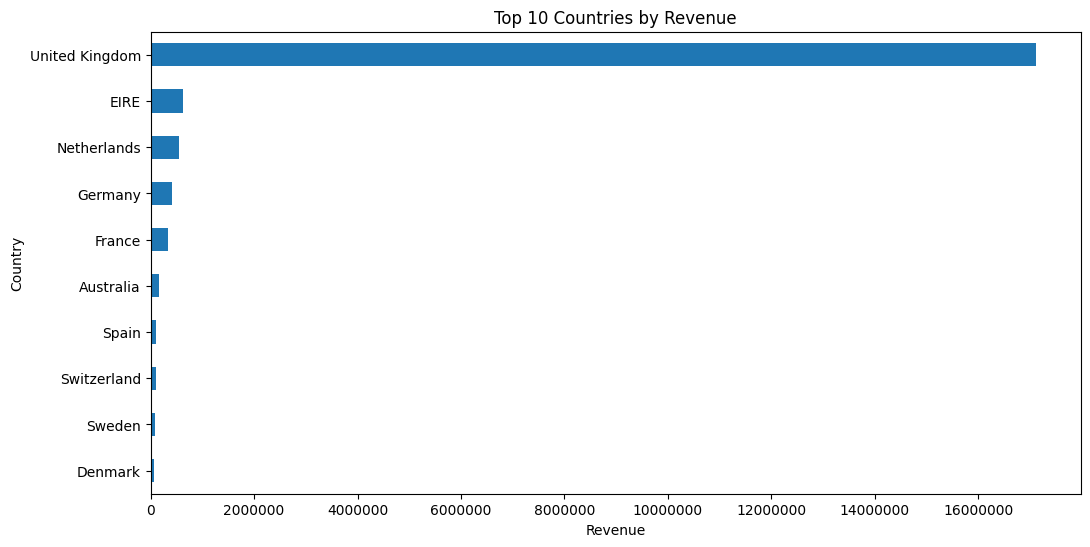

In [35]:
country_revenue = df.groupby('country')['revenue'].sum().sort_values(ascending=False).head(10)

country_revenue.sort_values().plot(
    kind='barh',
    figsize=(12,6)
)

plt.title('Top 10 Countries by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Country')

plt.ticklabel_format(style='plain', axis='x')

plt.show()

### Insights

1. The United Kingdom is the dominant revenue contributor, generating significantly more revenue than all other countries combined.
2. Revenue is highly concentrated in the UK market which indicates strong dependence on a single country.
3. The revenue gap between the UK and other countries highlights potential opportunities for international market expansion.

## Customer Analysis

In [36]:
top_customers = df.groupby('customer_id')['revenue'].sum().sort_values(ascending = False).head(10)
top_customers

customer_id
18102.0    580987.04
14646.0    528602.52
14156.0    304719.88
14911.0    279492.79
17450.0    244784.25
13694.0    195640.69
17511.0    172132.87
16446.0    168472.50
16684.0    147142.77
12415.0    144383.37
Name: revenue, dtype: float64

### Insights

1. The top 3 customers contribute significantly more revenue than the remaining customers, indicating revenue concentration.
2. The gap between top customers and the rest suggests a VIP customer segment worth retaining.
3. Customer retention strategies should prioritize the highest revenue customers to maximize business value.

## Repeat Customers

In [37]:
repeat_customers = df.groupby('customer_id')['invoice'].nunique().sort_values(ascending=False).head(10)
repeat_customers

customer_id
14911.0    376
12748.0    324
17841.0    211
15311.0    207
13089.0    203
14606.0    190
17850.0    155
14646.0    151
18102.0    145
14156.0    145
Name: invoice, dtype: int64

### Insights

1. Customer 14911 is the most frequent buyer but not the highest revenue contributor, suggesting they make smaller but more frequent purchases.
2. Customer 18102 is the highest revenue contributor but is not the most frequent buyer.
3. High purchase frequency does not always meant to generate highest revenue contribution.
4. Loyal customers should be targeted with retention programs and personalized promotions.

## Revenue by hour of the Day

In [38]:
df['hour'] = df['invoicedate'].dt.hour

In [39]:
hourly_sales = df.groupby('hour')['revenue'].sum()

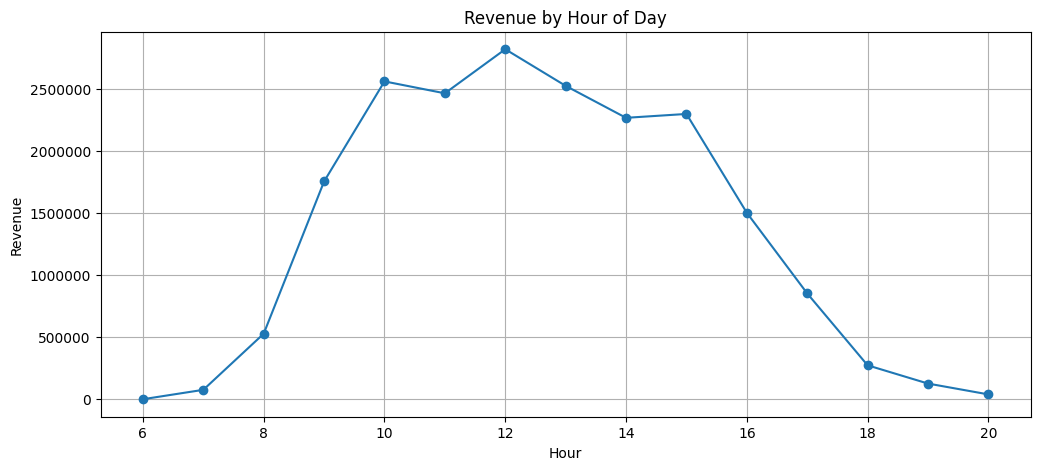

In [40]:
plt.figure(figsize=(12,5))
hourly_sales.plot(marker='o')
plt.title('Revenue by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Revenue')

plt.ticklabel_format(style='plain', axis='y')

plt.grid(True)

plt.show()

### Insights

1. Revenue rises sharply between 8 AM and 10 AM, indicating strong late morning customer activity.
2. Revenue peaks at 12 PM, making midday the most profitable hour of the day.
3. After 3 PM, revenue declines steadily, suggesting reduced customer activity in the evening.
4. Revenue drops significantly after 5 PM, indicating limited sales contribution from late hours.
5. Very little revenue is generated before 8 AM and after 6 PM.

# Conclusion

1. The analysis shows that a few products contribute most of the sales and revenue.
2. Home decor and gift related products are the most popular among customers.
3. Most of the revenue comes from the United Kingdom, while countries like EIRE and the Netherlands also contribute significantly.
4. Some customers make frequent purchases and generate high revenue, making them important to the business.
5. Sales are highest during the middle of the day, especially between 10 AM and 3 PM.

# Business Recommendations

1. Focus inventory and marketing efforts on top selling and top revenue products to maximize sales and profitability.
2. Focus on retaining loyal and high-value customers through customer engagement strategies.
3. Explore ways to increase sales in countries outside the United Kingdom to reduce dependence on a single market.
4. Investigate why sales are lower during early morning and evening hours and test strategies to improve performance during those periods.
5. Further analyze customer purchasing patterns to better understand what drives repeat purchases.